In [2]:
# ============================================================
# ✅ IMPORTS
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

In [5]:
# ============================================================
# ✅ PATH SETUP
# ============================================================
TRAIN_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/train"
if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Train directory not found: {TRAIN_DIR}")

# ============================================================
# ✅ DATA GENERATORS
# ============================================================
batch_size = 16
target_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=11,
    width_shift_range=0.14,
    height_shift_range=0.14,
    shear_range=0.17,
    zoom_range=0.20,
    brightness_range=[0.95, 1.15],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=42
)

num_classes = len(train_generator.class_indices)
print("Detected classes:", train_generator.class_indices)
print("Number of classes:", num_classes)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Detected classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Number of classes: 4


In [6]:
# ============================================================
# ✅ VGG16 MODEL (Instead of ResNet101)
# ============================================================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True  # fine-tuning enabled

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ============================================================
# ✅ COMPILE MODEL
# ============================================================
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ============================================================
# ✅ CALLBACKS
# ============================================================
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# ============================================================
# ✅ TRAINING
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,02

 Total params: 14,849,092 (56.64 MB)

 Trainable params: 14,848,068 (56.64 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 97s 358ms/step - accuracy: 0.6104 - loss: 1.3132 - val_accuracy: 0.4850 - val_loss: 1.9504 - learning_rate: 1.0000e-04
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 85s 336ms/step - accuracy: 0.8485 - loss: 0.7372 - val_accuracy: 0.7705 - val_loss: 1.0665 - learning_rate: 1.0000e-04
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 84s 336ms/step - accuracy: 0.8997 - loss: 0.5538 - val_accuracy: 0.8397 - val_loss: 0.7799 - learning_rate: 1.0000e-04
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 84s 336ms/step - accuracy: 0.9152 - loss: 0.4942 - val_accuracy: 0.8427 - val_loss: 0.7270 - learning_rate: 1.0000e-04
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 84s 335ms/step - accuracy: 0.9322 - loss: 0.4242 - val_accuracy: 0.7766 - val_loss: 0.8774 - learning_rate: 1.0000e-04
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 84s 335ms/step - accuracy: 0.9352 - loss: 0.3879 - val_accuracy: 0.6693 - val_loss: 1.5874 - learning_rate: 1.0000e-04
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━

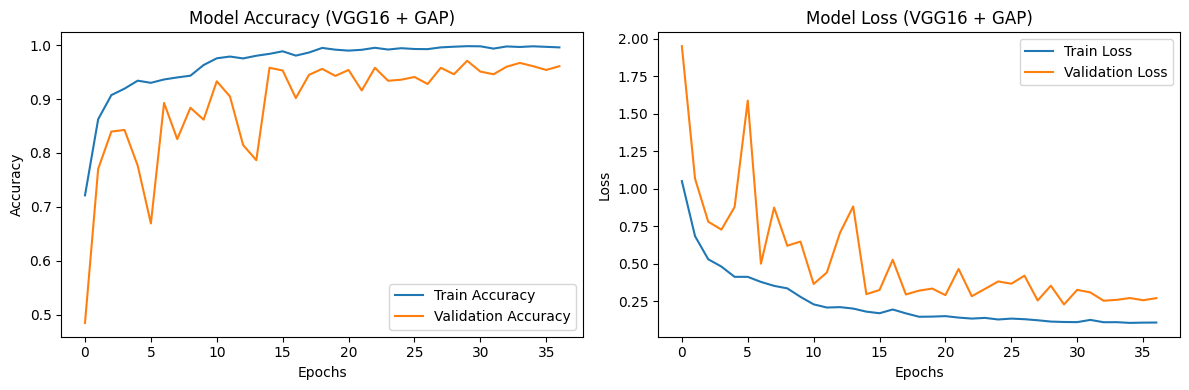

✅ Training curves saved.


In [11]:
OUTPUT_DIR = "/kaggle/working/vgg16_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# ✅ SAVE TRAINING CURVES
# ============================================================
curve_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (VGG16 + GAP)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (VGG16 + GAP)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(curve_path)
plt.show()

print("✅ Training curves saved.")


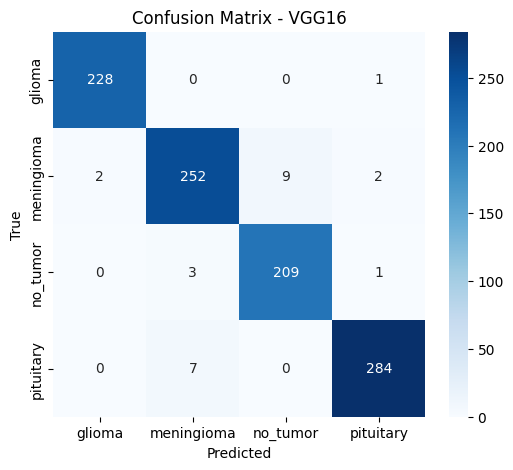

✅ Confusion matrix saved.


In [15]:
# ============================================================
# ✅ CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
class_names = list(val_generator.class_indices.keys())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - VGG16")

cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path)
plt.show()

# Save raw matrix
np.save(os.path.join(OUTPUT_DIR, "confusion_matrix.npy"), cm)

print("✅ Confusion matrix saved.")


In [19]:
# ============================================================
# ✅ CLASSIFICATION REPORT
# ============================================================
val_generator.reset()
pred_probs = model.predict(val_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(val_generator.class_indices.keys())))

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"\n✅ Accuracy:  {acc * 100:.2f}%")
print(f"✅ Precision: {prec * 100:.2f}%")
print(f"✅ Recall:    {rec * 100:.2f}%")
print(f"✅ F1-Score:  {f1 * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step

Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      0.99      0.99       229
  meningioma       0.94      0.95      0.95       265
    no_tumor       0.96      0.98      0.97       213
   pituitary       0.98      0.97      0.97       291

    accuracy                           0.97       998
   macro avg       0.97      0.97      0.97       998
weighted avg       0.97      0.97      0.97       998


✅ Accuracy:  96.99%
✅ Precision: 97.01%
✅ Recall:    97.13%
✅ F1-Score:  97.07%


In [21]:
# ============================================================
# ✅ FINAL SAVE BLOCK (ALL FILES INCLUDED)
# ============================================================

import os
import zipfile
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import FileLink, display

# Create output folder
OUTPUT_DIR = "/kaggle/working/vgg16_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

class_names = list(val_generator.class_indices.keys())

# ============================================================
# ✅ SAVE TRAINING CURVES
# ============================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (VGG16 + GAP)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (VGG16 + GAP)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"))
plt.close()

print("✅ Training curves saved.")

# ============================================================
# ✅ CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - VGG16")

plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.close()

np.save(os.path.join(OUTPUT_DIR, "confusion_matrix.npy"), cm)

print("✅ Confusion matrix saved.")

# ============================================================
# ✅ SAVE CLASSIFICATION REPORT (CSV)
# ============================================================
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report.csv"))

print("✅ Classification report saved.")

# ============================================================
# ✅ SAVE SUMMARY METRICS
# ============================================================
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"],
    "Score": [acc, prec, rec, f1]
})

summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"), index=False)

print("✅ Summary metrics saved.")

# ============================================================
# ✅ SAVE PREDICTIONS CSV
# ============================================================
pred_df = pd.DataFrame({
    "true_label_index": y_true,
    "predicted_label_index": y_pred,
    "true_label": [class_names[i] for i in y_true],
    "predicted_label": [class_names[i] for i in y_pred]
})

pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions.csv"), index=False)

print("✅ Predictions file saved.")

# ============================================================
# ✅ SAVE TEXT REPORT (Readable)
# ============================================================
with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write("Classification Report\n\n")
    f.write(classification_report(y_true, y_pred, target_names=class_names))
    f.write("\n\n")
    f.write(f"Accuracy:  {acc * 100:.2f}%\n")
    f.write(f"Precision: {prec * 100:.2f}%\n")
    f.write(f"Recall:    {rec * 100:.2f}%\n")
    f.write(f"F1-Score:  {f1 * 100:.2f}%\n")

print("✅ Text report saved.")

# ============================================================
# ✅ ZIP EVERYTHING
# ============================================================
zip_path = "/kaggle/working/vgg16_results.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, file), file)

print(f"\n📦 All results saved to: {zip_path}")

display(FileLink(zip_path))

✅ Training curves saved.
✅ Confusion matrix saved.
✅ Classification report saved.
✅ Summary metrics saved.
✅ Predictions file saved.
✅ Text report saved.

📦 All results saved to: /kaggle/working/vgg16_results.zip


/kaggle/working/vgg16_results.zip